In [1]:
import lasio
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import RobustScaler

In [2]:
# download LAs-file
las = lasio.read("data/159-19BT2_LFP.las")

print("Which curves are available:", [curve.mnemonic for curve in las.curves])

Only engine='normal' can read wrapped files


Which curves are available: ['DEPTH', 'LFP_AI', 'LFP_AI_B', 'LFP_AI_G', 'LFP_AI_LOG', 'LFP_AI_O', 'LFP_AI_V', 'LFP_API', 'LFP_BADDATA', 'LFP_BVWE', 'LFP_BVWT', 'LFP_COAL', 'LFP_DT', 'LFP_DT_B', 'LFP_DT_G', 'LFP_DT_LOG', 'LFP_DT_O', 'LFP_DT_SYNT', 'LFP_DT_V', 'LFP_DTCORFSFLAG', 'LFP_DTS', 'LFP_DTS_B', 'LFP_DTS_G', 'LFP_DTS_GC', 'LFP_DTS_LOG', 'LFP_DTS_O', 'LFP_DTS_V', 'LFP_EI_HILT_B', 'LFP_EI_HILT_G', 'LFP_EI_HILT_O', 'LFP_EI_HILT_V', 'LFP_GAS', 'LFP_GOR', 'LFP_GR', 'LFP_GRMAX', 'LFP_GRMIN', 'LFP_KFLG', 'LFP_KFLMF', 'LFP_KFLO', 'LFP_KFLW', 'LFP_KROCKV', 'LFP_KRROCKV', 'LFP_KSKEL', 'LFP_KVROCKV', 'LFP_MODEL', 'LFP_NPHI', 'LFP_NPHISH', 'LFP_OIL', 'LFP_PHIE', 'LFP_PHIEC', 'LFP_PHIEWC', 'LFP_PHIT', 'LFP_PHITC', 'LFP_PHITWC', 'LFP_PR', 'LFP_PR_B', 'LFP_PR_G', 'LFP_PR_LOG', 'LFP_PR_O', 'LFP_PR_SH_SYNT', 'LFP_PR_SS_B_SYNT', 'LFP_PR_SS_G_SYNT', 'LFP_PR_SS_O_SYNT', 'LFP_PR_V', 'LFP_PRESS', 'LFP_RHOB', 'LFP_RHOB_B', 'LFP_RHOB_G', 'LFP_RHOB_LOG', 'LFP_RHOB_O', 'LFP_RHOB_SYNT', 'LFP_RHOB_V', 'LFP_R

In [3]:
# Convert to pandas DataFrame
df = las.df()

In [4]:
gr_col = 'LFP_GR' 
neu_col = 'LFP_NPHI'

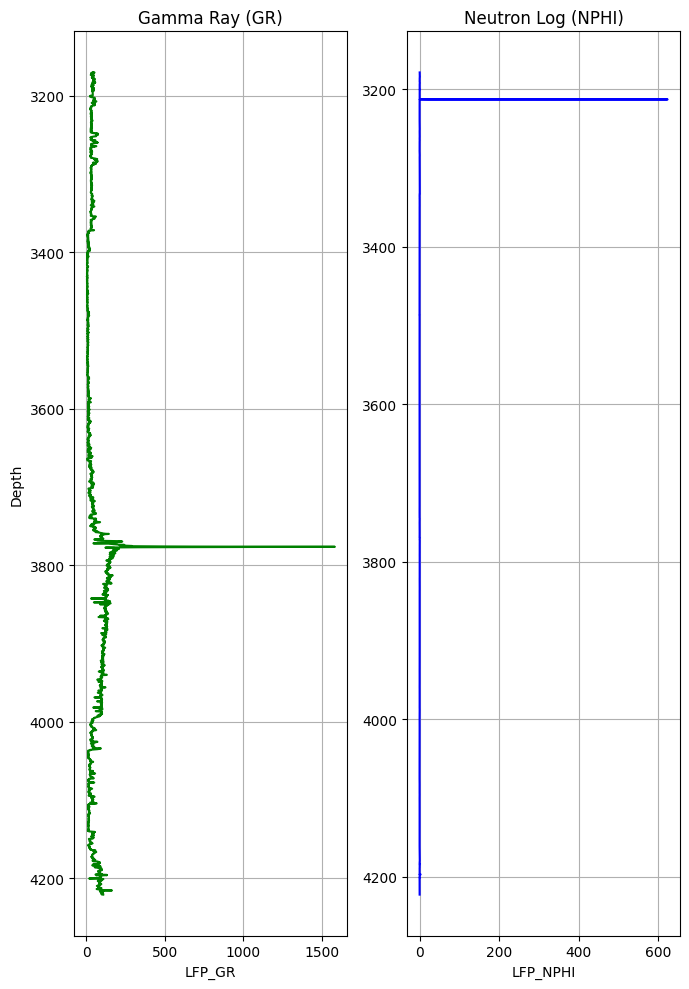

In [5]:
if gr_col is not None:
    num_plots = 2 if neu_col else 1
    fig, axes = plt.subplots(1, num_plots, figsize=(7, 10))

    # Гамма-каротаж
    ax0 = axes[0] if num_plots > 1 else axes
    ax0.plot(df[gr_col], df.index, 'green')
    ax0.set_xlabel(gr_col)
    ax0.set_ylabel("Depth")
    ax0.invert_yaxis()
    ax0.grid(True)
    ax0.set_title("Gamma Ray (GR)")

    if neu_col:
        axes[1].plot(df[neu_col], df.index, 'blue')
        axes[1].set_xlabel(neu_col)
        axes[1].invert_yaxis()
        axes[1].grid(True)
        axes[1].set_title("Neutron Log (NPHI)")

    plt.tight_layout()
    plt.show()
else:
    print("Failed to create plot — GR column not found.")

In [6]:
target_curves = ['LFP_GR', 'LFP_NPHI']
df_clean = df[target_curves].copy()
depth = df.index 

In [7]:
scaler = RobustScaler()
scaler_data = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(scaler_data, columns=target_curves, index=depth)

In [8]:
def add_synthetic_noise(signal, noise_std=0.1, spike_prob=0.01, spike_intensity=5, 
                        missing_interval_prob=0.005, missing_interval_length=20, seed=42):
    
    rng = np.random.default_rng(seed)
    noisy = signal.copy()
    mask = np.zeros(len(signal), dtype=bool)

    # Gaussian noise
    noisy += rng.normal(0, noise_std, size=signal.shape)

    # Random spikes
    spike_indices = rng.random(len(signal)) < spike_prob
    direction = rng.choice([-1, 1], size=spike_indices.sum())
    noisy[spike_indices] += direction * spike_intensity * (0.5 + rng.random(spike_indices.sum()))

    # Missing intervals
    i = 0
    while i < len(signal):
        if rng.random() < missing_interval_prob:
            gap_length = rng.integers(2, missing_interval_length + 1)
            gap_length = min(gap_length, len(signal) - i)
            mask[i:i + gap_length] = True
            noisy[i:i + gap_length] = np.nan
            i += gap_length
        else:
            i += 1
    return noisy, mask

In [ ]:
noisy_arrays = []
mask_arrays = []
for col in target_curves:
    sig = df_scaled[col].values
    noisy, mask = add_synthetic_noise(sig, noise_std=0.08, spike_prob=0.005, spike_intensity=4.0,
                                     missing_interval_prob=0.3, missing_interval_length=30)
    noisy_arrays.append(noisy)
    mask_arrays.append(mask)    

df_noisy = pd.DataFrame(np.column_stack(noisy_arrays), columns=[f'{col}_noisy' for col in target_curves], index=depth)
mask_combined = np.column_stack(mask_arrays)

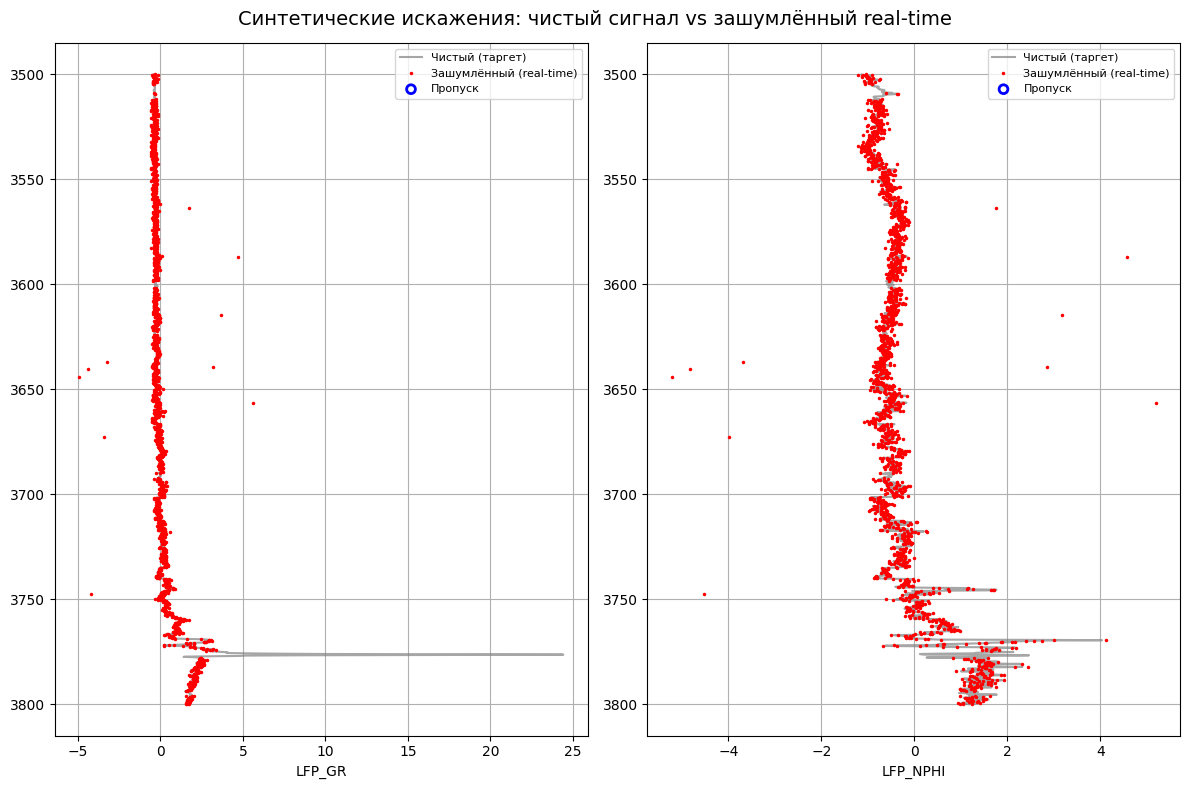

In [14]:
# Visualize original vs noisy data
depth_slice = (depth >= 3500) & (depth <= 3800)
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for i, col in enumerate(target_curves):
    ax = axes[i]
    ax.plot(df_scaled.loc[depth_slice, col], depth[depth_slice], 'grey', label='Чистый (таргет)', alpha=0.7)
    ax.plot(df_noisy.loc[depth_slice, f"{col}_noisy"], depth[depth_slice], 'r.', markersize=3, label='Зашумлённый (real-time)')
    # Отмечаем пропуски
    missing_idx = depth_slice & mask_combined[:, i]
    ax.scatter(df_noisy.loc[missing_idx, f"{col}_noisy"], depth[missing_idx], color='none', edgecolor='blue', s=40, linewidth=2, label='Пропуск')
    ax.invert_yaxis()
    ax.set_xlabel(col)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True)
plt.suptitle("Синтетические искажения: чистый сигнал vs зашумлённый real-time", fontsize=14)
plt.tight_layout()
plt.show()